In [46]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
)

df.shape


(253680, 22)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [48]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


In [49]:
df.duplicated().sum()

np.int64(24206)

In [50]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
80704,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
152374,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
91414,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
238843,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
48850,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,8.0


In [51]:
dup_counts = df[df.duplicated(keep=False)].groupby(list(df.columns)).size()
dup_counts.describe()

count    11369.000000
mean         3.129123
std          3.220553
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         59.000000
dtype: float64

In [52]:
dup_counts.sort_values(ascending=False).head(10)

Diabetes_binary  HighBP  HighChol  CholCheck  BMI   Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age  Education  Income
0.0              0.0     0.0       1.0        21.0  0.0     0.0     0.0                   1.0           1.0     1.0      0.0                1.0            0.0          1.0      0.0       0.0       0.0       0.0  6.0  6.0        8.0       59
                                              23.0  0.0     0.0     0.0                   1.0           1.0     1.0      0.0                1.0            0.0          1.0      0.0       0.0       0.0       0.0  6.0  6.0        8.0       55
                                                                                                                                                                                                                    7.0  6.0        8.0       53
                                          

In [53]:
df['BMI'].sort_values(ascending=False).head(20)

76532     98.0
79554     98.0
79507     98.0
79478     98.0
76394     98.0
76396     98.0
76370     98.0
36324     96.0
79522     95.0
79418     95.0
76527     95.0
79350     95.0
76371     95.0
79544     95.0
76366     95.0
76353     95.0
76373     95.0
206389    95.0
244309    95.0
79492     95.0
Name: BMI, dtype: float64

In [54]:
df['BMI'].sort_values(ascending=True).head(10)

98002     12.0
210863    12.0
136036    12.0
49827     12.0
239607    12.0
177462    12.0
219308    13.0
80280     13.0
102782    13.0
208779    13.0
Name: BMI, dtype: float64

In [55]:
df['Diabetes_binary'].value_counts(normalize=True)


Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64

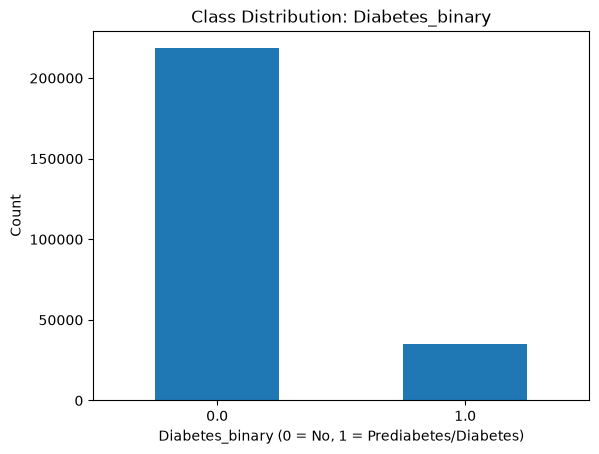

In [56]:
import matplotlib.pyplot as plt

df['Diabetes_binary'].value_counts().plot(kind='bar')
plt.title('Class Distribution: Diabetes_binary')
plt.xlabel('Diabetes_binary (0 = No, 1 = Prediabetes/Diabetes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [57]:
import pandas as pd

df = pd.read_csv(
    "../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
)

df.shape

(253680, 22)

In [58]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [59]:
df.shape

(253680, 22)

Task 2: Data Acquisition, Inspection and Documentation

This notebook loads and inspects the CDC Diabetes Health Indicators dataset before data cleansing and transformation.

2.1 Data acquisition

The CDC Diabetes Health Indicators dataset was obtained from the UCI Machine Learning Repository and accessed on 24 August 2026.

Source: https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators

The dataset originates from the CDC's 2015 Behavioral Risk Factor Surveillance System (BRFSS). The dataset is available under the CC0: Public Domain licence.

The unbalanced binary dataset was selected because it contains all 253,680 survey responses. Its target variable is Diabetes_binary, where 0 represents no diabetes and 1 represents prediabetes or diabetes.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


2.2 Initial data preview

In [61]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [62]:
df.tail()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [63]:
rows, columns = df.shape

print("Number of records:", rows)
print("Total number of columns:", columns)
print("Number of predictive features:", columns - 1)
print("Number of target variables: 1")

Number of records: 253680
Total number of columns: 22
Number of predictive features: 21
Number of target variables: 1


Column names and data types

In [64]:
print("--- Column names ---")
print(df.columns.tolist())

print("\n--- Data types ---")
print(df.dtypes)

--- Column names ---
['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

--- Data types ---
Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income 

All 22 columns are currently stored using the float64 data type. However, most variables represent binary or ordinal categories rather than continuous decimal measurements. For example, HighBP uses 0.0 for no and 1.0 for yes. These variables may need to be converted to more appropriate data types during data cleansing and transformation.

In [65]:
print("--- Missing values ---")
print(df.isna().sum())

print("\nTotal missing values:", df.isna().sum().sum())

--- Missing values ---
Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total missing values: 0


No missing values were identified. All 22 columns contained complete data for the 253,680 records.

Duplicate-record inspection

In [66]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print("Duplicate records:", duplicate_count)
print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Duplicate records: 24206
Duplicate percentage: 9.54 %


A total of 24,206 records matched an earlier record, representing approximately 9.54% of the dataset. However, the data does not contain a unique participant identifier. Because the features are mostly broad survey categories, separate participants may provide identical responses. These records were documented but not removed during Task 2.

In [67]:
duplicate_records = df[df.duplicated(keep=False)]

duplicate_records.sort_values(
    by=list(df.columns)
).head(10)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
4517,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
207307,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,8.0,6.0,8.0
42369,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
108949,0.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
17475,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
80704,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
152374,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,6.0,8.0
91414,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
238843,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,6.0,8.0
48850,0.0,0.0,0.0,0.0,19.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,8.0


Examples of repeated records were displayed for inspection. Identical values across all columns do not provide enough evidence to conclude that the records represent the same participant.

Unique-value inspection

In [68]:
print("--- Number of unique values ---")
print(df.nunique())

--- Number of unique values ---
Diabetes_binary          2
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64


In [69]:
print("--- Unique values in each column ---")

for col in df.columns:
    values = sorted(df[col].unique().tolist())
    print(col, "->", values)

--- Unique values in each column ---
Diabetes_binary -> [0.0, 1.0]
HighBP -> [0.0, 1.0]
HighChol -> [0.0, 1.0]
CholCheck -> [0.0, 1.0]
BMI -> [12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 95.0, 96.0, 98.0]
Smoker -> [0.0, 1.0]
Stroke -> [0.0, 1.0]
HeartDiseaseorAttack -> [0.0, 1.0]
PhysActivity -> [0.0, 1.0]
Fruits -> [0.0, 1.0]
Veggies -> [0.0, 1.0]
HvyAlcoholConsump -> [0.0, 1.0]
AnyHealthcare -> [0.0, 1.0]
NoDocbcCost -> [0.0, 1.0]
GenHlth -> [1.0, 2.0, 3.0, 4.0, 5.0]
MentHlth -> [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13



The unique values in each column were examined to identify inconsistent categories and invalid entries. The results show that the binary variables contain only 0.0 and 1.0, which is consistent with their documented coding.

The ordinal variables also remain within their expected ranges. For example, GenHlth contains categories from 1.0 to 5.0, Age contains categories from 1.0 to 13.0, Education contains categories from 1.0 to 6.0, and Income contains categories from 1.0 to 8.0.

BMI, MentHlth and PhysHlth contain a larger number of values because they represent measurements or counts rather than simple categories. No inconsistent category codes were identified during this inspection.

The values are currently stored as float64 values, which explains why they appear with decimal points, such as 0.0 and 1.0. Appropriate data-type conversion will be considered during the data-cleansing and transformation stage.

Summary statistics and value ranges

In [70]:
print("--- Summary statistics ---")
df.describe().T

--- Summary statistics ---


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


The summary statistics showed that BMI ranged from 12 to 98, with a mean of approximately 28.38 and a median of 27. GenHlth ranged from 1 to 5, Age from 1 to 13, Education from 1 to 6, and Income from 1 to 8. MentHlth and PhysHlth both ranged from 0 to 30 days. All binary columns had a minimum of 0 and a maximum of 1.

Invalid and inconsistent value inspection

In [71]:
binary_columns = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
    "Diabetes_binary"
]

for col in binary_columns:
    bad = df[~df[col].isin([0, 1])]
    print(col, "invalid values:", len(bad))

HighBP invalid values: 0
HighChol invalid values: 0
CholCheck invalid values: 0
Smoker invalid values: 0
Stroke invalid values: 0
HeartDiseaseorAttack invalid values: 0
PhysActivity invalid values: 0
Fruits invalid values: 0
Veggies invalid values: 0
HvyAlcoholConsump invalid values: 0
AnyHealthcare invalid values: 0
NoDocbcCost invalid values: 0
DiffWalk invalid values: 0
Sex invalid values: 0
Diabetes_binary invalid values: 0


In [72]:
range_checks = {
    "GenHlth": (1, 5),
    "MentHlth": (0, 30),
    "PhysHlth": (0, 30),
    "Age": (1, 13),
    "Education": (1, 6),
    "Income": (1, 8)
}

for col, limits in range_checks.items():
    minimum = limits[0]
    maximum = limits[1]

    bad = df[
        (df[col] < minimum) |
        (df[col] > maximum)
    ]

    print(col, "out-of-range records:", len(bad))

GenHlth out-of-range records: 0
MentHlth out-of-range records: 0
PhysHlth out-of-range records: 0
Age out-of-range records: 0
Education out-of-range records: 0
Income out-of-range records: 0


No invalid values were found in the binary or ordinal columns. All checked variables remained within the expected ranges specified in the dataset documentation. No inconsistent text formatting was present because all variables were numerically encoded.

In [73]:
print("--- Lowest BMI values ---")
print(df["BMI"].sort_values().head(10))

print("\n--- Highest BMI values ---")
print(df["BMI"].sort_values(ascending=False).head(20))

--- Lowest BMI values ---
98002     12.0
210863    12.0
136036    12.0
49827     12.0
239607    12.0
177462    12.0
219308    13.0
80280     13.0
102782    13.0
208779    13.0
Name: BMI, dtype: float64

--- Highest BMI values ---
76532     98.0
79554     98.0
79507     98.0
79478     98.0
76394     98.0
76396     98.0
76370     98.0
36324     96.0
79522     95.0
79418     95.0
76527     95.0
79350     95.0
76371     95.0
79544     95.0
76366     95.0
76353     95.0
76373     95.0
206389    95.0
244309    95.0
79492     95.0
Name: BMI, dtype: float64


In [74]:
print("BMI below 15:", len(df[df["BMI"] < 15]))
print("BMI above 60:", len(df[df["BMI"] > 60]))

BMI below 15: 68
BMI above 60: 805


BMI ranged from 12 to 98. Values at both ends of the range are unusual and were identified as potential outliers. However, unusual BMI values are not automatically invalid. They were retained during Task 2 and will be investigated further during data cleansing.

Target-variable distribution

In [75]:
print("--- Diabetes class counts ---")
print(df["Diabetes_binary"].value_counts())

print("\n--- Diabetes class percentages ---")
print(
    df["Diabetes_binary"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

--- Diabetes class counts ---
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

--- Diabetes class percentages ---
Diabetes_binary
0.0    86.07
1.0    13.93
Name: proportion, dtype: float64


Approximately 86.07% of participants were labelled as having no diabetes, while 13.93% were labelled as having prediabetes or diabetes. This shows that the target variable is imbalanced.

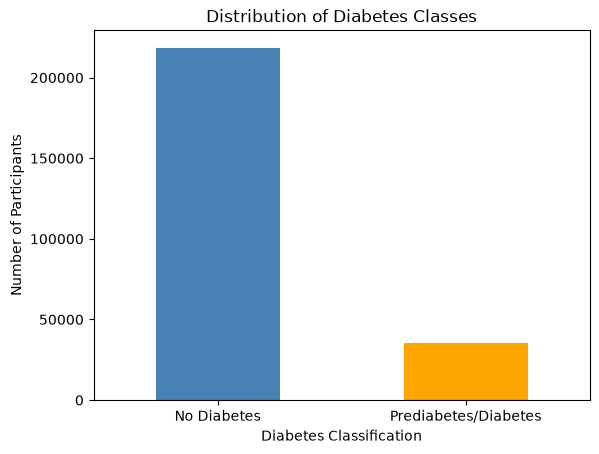

In [76]:
import matplotlib.pyplot as plt

df["Diabetes_binary"].value_counts().sort_index().plot(
    kind="bar",
    color=["steelblue", "orange"]
)

plt.title("Distribution of Diabetes Classes")
plt.xlabel("Diabetes Classification")
plt.ylabel("Number of Participants")
plt.xticks(
    ticks=[0, 1],
    labels=["No Diabetes", "Prediabetes/Diabetes"],
    rotation=0
)

plt.show()

The class-distribution graph shows that the number of participants without diabetes is substantially larger than the number with prediabetes or diabetes. This imbalance will need to be considered during later analysis and modelling.

Variable meanings

- HighBP: high blood pressure, where 0 = no and 1 = yes.
- HighChol: high cholesterol, where 0 = no and 1 = yes.
- CholCheck: cholesterol check within five years.
- BMI: Body Mass Index.
- Smoker: smoked at least 100 cigarettes during their lifetime.
- Stroke: history of stroke.
- HeartDiseaseorAttack: history of coronary heart disease or heart attack.
- PhysActivity: physical activity during the previous 30 days.
- Fruits: consumes fruit at least once per day.
- Veggies: consumes vegetables at least once per day.
- HvyAlcoholConsump: heavy alcohol consumption.
- AnyHealthcare: has healthcare coverage.
- NoDocbcCost: unable to visit a doctor because of cost.
- GenHlth: general health category from 1 = excellent to 5 = poor.
- MentHlth: number of poor mental-health days in the previous 30 days.
- PhysHlth: number of poor physical-health days in the previous 30 days.
- DiffWalk: serious difficulty walking or climbing stairs.
- Sex: 0 = female and 1 = male.
- Age: age category from 1 to 13.
- Education: education category from 1 to 6.
- Income: income category from 1 to 8.
- Diabetes_binary: 0 = no diabetes and 1 = prediabetes or diabetes.

Assumptions made during data interpretation

1. Each row represents a separate BRFSS survey participant.
2. Diabetes_binary is the target variable.
3. Binary values are treated as categories rather than numerical measurements.
4. Age, Education, Income and GenHlth are ordered categories.
5. Identical records are not automatically treated as accidental duplicates because no unique participant identifier is available.
6. Extreme BMI values are considered potential outliers rather than confirmed errors.
7. The absence of missing values may be the result of preprocessing performed by the dataset creator.
8. The survey responses are self-reported and may be affected by recall or response bias.
9. The data represents surveyed adults in the United States during 2015 and may not generalise to other countries or populations.